# Modèle 4 - MLP (Deep Learning)

Le MLP (Multilayer Perceptron) est un réseau de neurones multicouches implémenté en PyTorch.
Il est capable de capturer des interactions non linéaires complexes entre les features
que les modèles classiques pourraient rater.

**Justification de l'utilisation du Deep Learning ici :**
Le dataset contient 32 features initiales (et davantage après encodage OHE) avec des
interactions potentiellement non triviales entre comportements d'engagement, métriques
financières et indicateurs de satisfaction. Le MLP peut en théorie modéliser ces
interactions automatiquement.

**Limitation attendue :** Avec seulement 10 000 observations, le MLP risque de peiner
à surpasser XGBoost. On s'y attend et on le documentera dans la comparaison.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix
)
from src.models.mlflow_utils import setup_mlflow, log_pytorch_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositif utilisé : {DEVICE}")

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv').values.astype(np.float32)
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv').values.astype(np.float32)
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze().values.astype(np.float32)
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze().values.astype(np.float32)
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

INPUT_DIM = X_train.shape[1]
print(f"Dimension d'entrée : {INPUT_DIM} features")

Dispositif utilisé : cuda
Dimension d'entrée : 58 features


## 1. Architecture du réseau

In [2]:
class ChurnMLP(nn.Module):
    """
    Réseau MLP à 3 couches cachées pour la classification de churn.

    Architecture choisie :
    - Couches décroissantes (256 -> 128 -> 64) : progressivement plus abstraite
    - BatchNorm après chaque couche : stabilise et accélère l'entraînement
    - Dropout (0.3) : régularisation contre l'overfitting, critique avec 10k obs
    - ReLU : non-linéarité standard, évite le vanishing gradient vs sigmoid
    - Pas de sigmoid en sortie : BCEWithLogitsLoss l'applique en interne de façon
      numériquement plus stable ; on applique torch.sigmoid() manuellement à l'inférence
    """

    def __init__(self, input_dim: int, dropout_rate: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model = ChurnMLP(input_dim=INPUT_DIM, dropout_rate=0.3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNombre total de paramètres : {total_params:,}")

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=58, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre total de paramètres : 57,217


## 2. Préparation des DataLoaders

In [3]:
from torchvision.ops import sigmoid_focal_loss

X_train_t = torch.tensor(X_train).to(DEVICE)
y_train_t = torch.tensor(y_train).to(DEVICE)
X_test_t = torch.tensor(X_test).to(DEVICE)
y_test_t = torch.tensor(y_test).to(DEVICE)

BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos]).to(DEVICE)
print(f"Ratio negatifs/positifs (pos_weight) : {pos_weight.item():.2f}")

# Focal Loss (torchvision.ops.sigmoid_focal_loss) - conçue pour les datasets
# desequilibres. Elle down-pondère les exemples faciles (bien classés) via
# le facteur (1-pt)^gamma, pour que l'apprentissage se concentre sur les
# churners difficiles. alpha pondère la classe positive.
# gamma=2 et alpha=0.25 sont les valeurs de reference du papier original (RetinaNet).
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

def focal_criterion(logits, targets):
    return sigmoid_focal_loss(
        logits, targets,
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        reduction='mean',
    )

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(f"Fonction de cout : Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})")

Ratio negatifs/positifs (pos_weight) : 8.79
Fonction de cout : Focal Loss (alpha=0.25, gamma=2.0)


## 3. Boucle d'entraînement

In [4]:
N_EPOCHS = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_hat = model(X_batch)
        loss = focal_criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    epoch_loss /= len(X_train_t)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_t)
        val_loss = focal_criterion(val_logits, y_test_t).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoque {epoch+1:3d}/{N_EPOCHS} | train_loss={epoch_loss:.4f} | val_loss={val_loss:.4f}")

model.load_state_dict(best_model_state)
print(f"\nMeilleure val_loss (Focal) : {best_val_loss:.4f}")

Epoque  10/50 | train_loss=0.0283 | val_loss=0.0294
Epoque  20/50 | train_loss=0.0248 | val_loss=0.0303
Epoque  30/50 | train_loss=0.0232 | val_loss=0.0310
Epoque  40/50 | train_loss=0.0225 | val_loss=0.0312
Epoque  50/50 | train_loss=0.0222 | val_loss=0.0313

Meilleure val_loss (Focal) : 0.0294


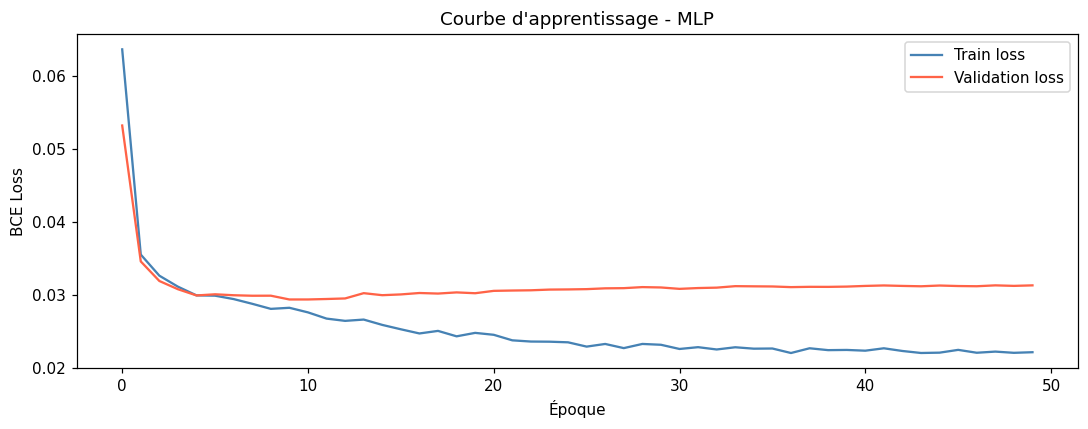

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss', color='steelblue')
ax.plot(val_losses, label='Validation loss', color='tomato')
ax.set_xlabel('Époque')
ax.set_ylabel('BCE Loss')
ax.set_title('Courbe d\'apprentissage - MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_mlp_learning_curve.png', bbox_inches='tight')
plt.show()

## 4. Évaluation

In [6]:
model.eval()
with torch.no_grad():
    # Le modèle sort des logits (pas de sigmoid final) - on applique sigmoid ici
    # pour obtenir des probabilités interprétables entre 0 et 1.
    y_proba = torch.sigmoid(model(X_test_t)).cpu().numpy()

y_pred = (y_proba >= 0.5).astype(int)
metrics = compute_classification_metrics(y_test.astype(int), y_pred, y_proba)
print_classification_report(y_test.astype(int), y_pred, 'MLP (Deep Learning)')

print("\nMétriques :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification - MLP (Deep Learning)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.90      1.00      0.95      1796
       Churn       0.00      0.00      0.00       204

    accuracy                           0.90      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.81      0.90      0.85      2000


Métriques :
  accuracy : 0.8980
  auc_roc : 0.7492
  f1_weighted : 0.8497
  f1_churn : 0.0000
  precision_churn : 0.0000
  recall_churn : 0.0000
  log_loss : 0.3533


## 4b. Optimisation du seuil de decision

Comme pour la Regression Logistique, le seuil par defaut de 0.5 peut etre
sous-optimal sur un dataset desequilibre. On cherche le seuil qui maximise
le F1-churn sur le jeu de test.

Seuil par defaut : 0.50  ->  F1-churn = 0.0000
Seuil optimal    : 0.2874  ->  F1-churn = 0.3423

Rapport de classification - MLP - seuil optimise (0.29)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.94      0.79      0.86      1796
       Churn       0.24      0.59      0.34       204

    accuracy                           0.77      2000
   macro avg       0.59      0.69      0.60      2000
weighted avg       0.87      0.77      0.81      2000


Metriques avec seuil optimise :
  accuracy : 0.7675
  auc_roc : 0.7492
  f1_weighted : 0.8061
  f1_churn : 0.3423
  precision_churn : 0.2406
  recall_churn : 0.5931
  log_loss : 0.3533


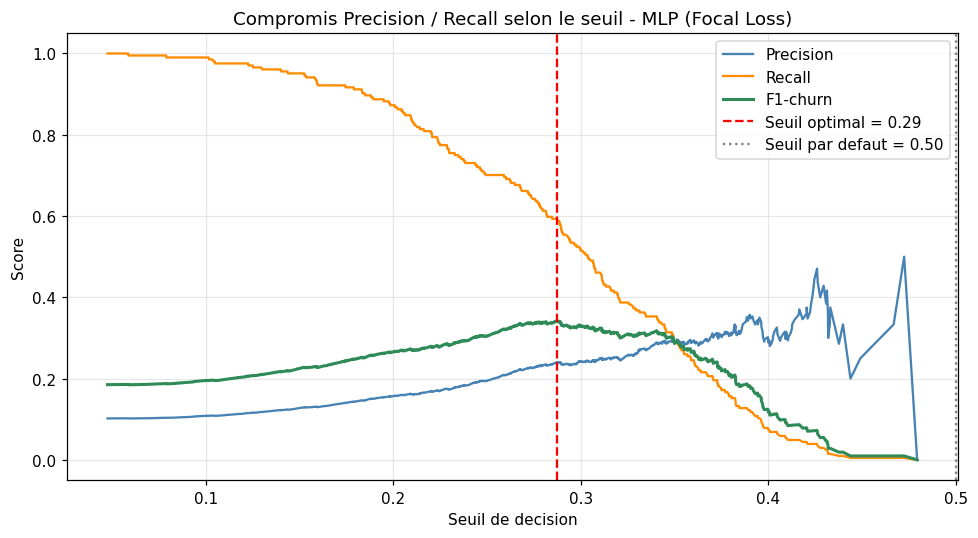

In [7]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test.astype(int), y_proba)
f1_scores_thr = (2 * precisions[:-1] * recalls[:-1]
                 / (precisions[:-1] + recalls[:-1] + 1e-9))

optimal_idx = np.argmax(f1_scores_thr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil par defaut : 0.50  ->  F1-churn = {f1_scores_thr[(np.abs(thresholds - 0.5)).argmin()]:.4f}")
print(f"Seuil optimal    : {optimal_threshold:.4f}  ->  F1-churn = {f1_scores_thr[optimal_idx]:.4f}")

y_pred_opt = (y_proba >= optimal_threshold).astype(int)
metrics_opt = compute_classification_metrics(y_test.astype(int), y_pred_opt, y_proba)
print_classification_report(y_test.astype(int), y_pred_opt, f"MLP - seuil optimise ({optimal_threshold:.2f})")

print("\nMetriques avec seuil optimise :")
for k, v in metrics_opt.items():
    print(f"  {k} : {v:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, recalls[:-1], label="Recall", color="darkorange")
ax.plot(thresholds, f1_scores_thr, label="F1-churn", color="seagreen", linewidth=2)
ax.axvline(optimal_threshold, color="red", linestyle="--",
           label=f"Seuil optimal = {optimal_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Seuil par defaut = 0.50")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Score")
ax.set_title("Compromis Precision / Recall selon le seuil - MLP (Focal Loss)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/fig_mlp_threshold.png", bbox_inches="tight")
plt.show()

## 5. Enregistrement dans MLflow

Les metriques loguees sont celles calculees avec le seuil optimise
(pas le seuil par defaut 0.5), pour une comparaison honnete entre modeles.

In [8]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'architecture': '256-128-64-1',
    'dropout_rate': 0.3,
    'n_epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'AdamW',
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'loss': 'FocalLoss',
    'focal_alpha': FOCAL_ALPHA,
    'focal_gamma': FOCAL_GAMMA,
    'threshold': float(optimal_threshold),
    'device': str(DEVICE),
}

run_id = log_pytorch_classification_run(
    model=model,
    model_name='MLP (PyTorch)',
    params=params,
    metrics=metrics_opt,
    X_train=X_train,
    X_test=X_test,
    input_dim=INPUT_DIM,
)

torch.save(model.state_dict(), PROCESSED_DIR / 'model_mlp_state.pth')
import json
(PROCESSED_DIR / 'threshold_mlp.json').write_text(
    json.dumps({'threshold': float(optimal_threshold)})
)
print(f"Run MLflow : {run_id}")
print(f"Seuil optimal sauvegarde : {optimal_threshold:.4f}")

Expérience MLflow : 'churn_classification' (id=1)
Run PyTorch enregistré : MLP (PyTorch) | run_id=98a89cb5c1e7432da51a7c2917ea2dd1
  AUC-ROC : 0.7492
🏃 View run MLP (PyTorch) at: http://localhost:5000/#/experiments/1/runs/98a89cb5c1e7432da51a7c2917ea2dd1
🧪 View experiment at: http://localhost:5000/#/experiments/1
Run MLflow : 98a89cb5c1e7432da51a7c2917ea2dd1
Seuil optimal sauvegarde : 0.2874


## 6. Recherche d'hyperparametres - Optuna

Optuna utilise une optimisation bayesienne (TPE - Tree-structured Parzen Estimator)
pour explorer l'espace des hyperparametres plus efficacement qu'une recherche aleatoire.
Contrairement a RandomizedSearchCV, il adapte les prochains essais en fonction
des resultats precedents pour converger plus vite vers la meilleure configuration.

In [9]:
import optuna
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_OPTUNA_EPOCHS = 15  # Entrainement rapide par trial pour comparer les tendances
N_TRIALS = 20

def objective(trial):
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    focal_alpha = trial.suggest_float('focal_alpha', 0.1, 0.5)
    focal_gamma = trial.suggest_float('focal_gamma', 0.5, 4.0)

    m = ChurnMLP(input_dim=INPUT_DIM, dropout_rate=dropout).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)

    def crit(logits, targets):
        return sigmoid_focal_loss(logits, targets,
                                  alpha=focal_alpha, gamma=focal_gamma,
                                  reduction='mean')

    dl = DataLoader(TensorDataset(X_train_t, y_train_t),
                    batch_size=batch_size, shuffle=True)

    m.train()
    for _ in range(N_OPTUNA_EPOCHS):
        for Xb, yb in dl:
            opt.zero_grad()
            crit(m(Xb), yb).backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        proba = torch.sigmoid(m(X_test_t)).cpu().numpy()

    return roc_auc_score(y_test.astype(int), proba)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMeilleurs hyperparametres Optuna ({N_TRIALS} trials) :")
for k, v in study.best_params.items():
    print(f"  {k} : {v:.4f}" if isinstance(v, float) else f"  {k} : {v}")
print(f"Meilleur AUC-ROC : {study.best_value:.4f}  (modele de base : {metrics_opt['auc_roc']:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]


Meilleurs hyperparametres Optuna (20 trials) :
  dropout : 0.4146
  lr : 0.0025
  batch_size : 256
  focal_alpha : 0.3868
  focal_gamma : 1.7542
Meilleur AUC-ROC : 0.7540  (modele de base : 0.7492)
